# Precision at Fixed Candidate Budgets (K = 10, 20, 30, 50) -- Presentation

14 ROIs (`images/extra_valid`), one seed per ROI (`seed_index = 0`).

In [1]:
import gc
import time
import sys

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils import compare as cp
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 220)

IMAGES_DIR = '../images/extra_valid'
SEED_INDEX = 0

CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
PEAK_MIN_DISTANCE = 7
SELF_HIT_RADIUS = 5.0
DEEP_FLOOR_Z = -1.5
MAX_PEAKS = 2_000_000

NMS_RADIUS_UM = ev.MIDOG_RADIUS_UM
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2
OTSU_WINDOW = tm.BASE_SIZE
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)

BUDGETS = (10, 20, 30, 50)

OUT_PER_ROI = '../results/precision_at_k_14roi_presentation_per_roi.csv'
OUT_BY_DOMAIN = '../results/precision_at_k_14roi_presentation_by_domain.csv'

In [2]:
def _odd_local(n, minimum=5):
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)


def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    '''Otsu-threshold `patch`; return the bbox of its largest connected component by area.

    (y0, y1, x0, x1), patch-local, half-open, or None when the component fails a gate.
    '''
    if patch.ndim != 2:
        raise ValueError(f'largest_cc_box needs a single-channel patch, got {patch.shape}')
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    regions = regionprops(label(binary, connectivity=2))
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    if largest.area < min_area or largest.area > max_area_frac * patch.size:
        return None
    if largest.solidity < min_solidity:
        return None
    y0, x0, y1, x1 = largest.bbox
    return int(y0), int(y1), int(x0), int(x1)


def draw_seed_with_retry(pool, rng, check_fn):
    working, retries = pool.copy(), 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError('seed pool exhausted -- no candidate passed check_fn')


def suppress(centers, scores, radius, seed_xy):
    keep = nms_by_distance(centers, scores, radius)
    c, s = centers[keep], scores[keep]
    if len(c):
        ok = np.hypot(c[:, 0] - seed_xy[0], c[:, 1] - seed_xy[1]) > SELF_HIT_RADIUS
        c, s = c[ok], s[ok]
    return c, s


def roi_files(images_dir=IMAGES_DIR):
    import os
    return sorted(f for f in os.listdir(images_dir) if f.endswith('.tiff'))

In [3]:
def run_roi(fn, image_id, domain, anns):
    path = f'{IMAGES_DIR}/{fn}'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    roi_shape = rgb.shape
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    del rgb
    gc.collect()

    gt = ds.image_annotations(anns, fn)
    seed_pool, _ = ss.agreement_pool(gt[gt['category_id'] == ds.MITOTIC])
    seed_pool = ss.border_filter(seed_pool, BORDER, roi_shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])

    def _check(row):
        p = tm.read_padded_patch(gray_inv, float(row['cx']), float(row['cy']), OTSU_WINDOW)
        return None if p is None else largest_cc_box(p, **LARGEST_CC_KW)

    seed, seed_box, _ = draw_seed_with_retry(seed_pool, rng, _check)
    y0, y1, x0, x1 = seed_box
    base_size = _odd_local(max(y1 - y0, x1 - x0))
    seed_xy = (float(seed['cx']), float(seed['cy']))
    seed_ann_id = int(seed['ann_id'])
    gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)
    n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    del gray_inv
    gc.collect()

    patch = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, base_size, CFG.scales, CFG.n_angles, CFG.flips)
    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, _, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    del hem_p, fused_p, valid_p, hem
    gc.collect()

    med, mad = tm.robust_stats(fused, valid)
    cut = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
    c, s = suppress(centers, scores, nms_radius, seed_xy)
    pool = pd.DataFrame({'cx': c[:, 0], 'cy': c[:, 1], 'score': s})

    arm = cp.Arm('tm_score_deep_floor', (lambda d=pool: d), rank_key='score',
                 seeded=True, z=DEEP_FLOOR_Z, z_dependent=True, nms_radius=nms_radius)
    ctx = dict(file_name=fn, tumor_type=domain, image_id=image_id)
    out = cp.evaluate_arms([arm], gt_eval, match_radius, roi_shape=(H, W), mpp=mpp,
                            budgets=BUDGETS, context=ctx)

    z_at_rank = {}
    for k in BUDGETS:
        z_at_rank[k] = (float(pool['score'].iloc[k - 1] - med) / mad) if len(pool) >= k else np.nan
    out['z_at_rank'] = out['budget'].map(z_at_rank)

    meta = dict(file_name=fn, tumor_type=domain, image_id=image_id,
                n_gt_mitotic=n_gt, n_detections=len(pool))
    del fused, valid, templates, patch, centers, scores, c, s
    gc.collect()
    return out, meta

In [4]:
images, annotations = ds.load_annotations('../databases/MIDOG++.json')
meta_ix = images.set_index('file_name')[['image_id', 'tumor_type']]
files = roi_files()

out_frames, roi_meta = [], []
for fn in files:
    image_id = int(meta_ix.loc[fn, 'image_id'])
    domain = meta_ix.loc[fn, 'tumor_type']
    out, m = run_roi(fn, image_id, domain, annotations)
    out_frames.append(out)
    roi_meta.append(m)
    gc.collect()

RAW = pd.concat(out_frames, ignore_index=True)
ROI = pd.DataFrame(roi_meta).set_index('file_name')

## Precision per ROI

In [5]:
RAW['precision_at_budget'] = RAW['tp_at_budget'] / RAW['budget_delivered']

order = ROI[['tumor_type']].reset_index().sort_values(['tumor_type', 'file_name'])

rows_a = []
for _, o in order.iterrows():
    fn = o['file_name']
    r = dict(file_name=fn, domain=o['tumor_type'],
             n_gt_mitotic=int(ROI.loc[fn, 'n_gt_mitotic']),
             n_detections=int(ROI.loc[fn, 'n_detections']))
    sub = RAW[RAW['file_name'] == fn].set_index('budget')
    for k in BUDGETS:
        r[f'z_at_rank_{k}'] = round(float(sub.loc[k, 'z_at_rank']), 3)
        r[f'budget_delivered_{k}'] = int(sub.loc[k, 'budget_delivered'])
        r[f'tp_at_{k}'] = int(sub.loc[k, 'tp_at_budget'])
        r[f'precision_at_{k}'] = round(float(sub.loc[k, 'precision_at_budget']), 4)
    rows_a.append(r)

TABLE_A = pd.DataFrame(rows_a)
TABLE_A.to_csv(OUT_PER_ROI, index=False)
TABLE_A

,file_name,domain,n_gt_mitotic,n_detections,z_at_rank_10,budget_delivered_10,tp_at_10,precision_at_10,z_at_rank_20,budget_delivered_20,tp_at_20,precision_at_20,z_at_rank_30,budget_delivered_30,tp_at_30,precision_at_30,z_at_rank_50,budget_delivered_50,tp_at_50,precision_at_50
0,300.tiff,canine cutaneous mast cell tumor,180,17940,8.523,10,7,0.7,7.794,20,14,0.70,7.577,30,20,0.6667,7.196,50,32,0.64
1,301.tiff,canine cutaneous mast cell tumor,217,17963,7.078,10,9,0.9,6.830,20,16,0.80,6.634,30,24,0.8000,6.431,50,38,0.76
2,201.tiff,canine lung cancer,17,15848,6.339,10,3,0.3,6.053,20,5,0.25,5.914,30,6,0.2000,5.623,50,11,0.22
3,233.tiff,canine lung cancer,17,17614,10.805,10,4,0.4,10.254,20,7,0.35,10.019,30,7,0.2333,9.462,50,10,0.20
4,245.tiff,canine lymphosarcoma,89,17552,5.281,10,1,0.1,5.125,20,1,0.05,4.994,30,1,0.0333,4.875,50,4,0.08
5,246.tiff,canine lymphosarcoma,115,17763,9.720,10,10,1.0,8.791,20,18,0.90,8.404,30,24,0.8000,7.667,50,32,0.64
6,459.tiff,canine soft tissue sarcoma,130,17994,7.604,10,5,0.5,7.008,20,10,0.50,6.886,30,15,0.5000,6.495,50,24,0.48
7,460.tiff,canine soft tissue sarcoma,35,15339,7.557,10,7,0.7,6.937,20,11,0.55,6.551,30,13,0.4333,6.264,50,17,0.34
8,013.tiff,human breast cancer,17,17200,20.260,10,4,0.4,18.340,20,5,0.25,17.592,30,6,0.2000,16.435,50,9,0.18
9,094.tiff,human breast cancer,81,18410,18.692,10,5,0.5,17.660,20,10,0.50,16.727,30,16,0.5333,15.546,50,25,0.50


## Precision per domain

In [6]:
rows_b = []
for (domain, k), g in RAW.groupby(['tumor_type', 'budget']):
    tp_sum = int(g['tp_at_budget'].sum())
    delivered_sum = int(g['budget_delivered'].sum())
    worst = g.loc[g['precision_at_budget'].idxmin()]
    rows_b.append(dict(
        domain=domain, n_roi=len(g), K=int(k),
        tp_sum=tp_sum, delivered_sum=delivered_sum,
        precision_pooled=round(tp_sum / delivered_sum, 4) if delivered_sum else np.nan,
        precision_worst_roi=round(float(worst['precision_at_budget']), 4),
        worst_roi_file=str(worst['file_name']),
    ))

TABLE_B = pd.DataFrame(rows_b).sort_values(['domain', 'K']).reset_index(drop=True)
TABLE_B.to_csv(OUT_BY_DOMAIN, index=False)
TABLE_B

,domain,n_roi,K,tp_sum,delivered_sum,precision_pooled,precision_worst_roi,worst_roi_file
0,canine cutaneous mast cell tumor,2,10,16,20,0.8000,0.7000,300.tiff
1,canine cutaneous mast cell tumor,2,20,30,40,0.7500,0.7000,300.tiff
2,canine cutaneous mast cell tumor,2,30,44,60,0.7333,0.6667,300.tiff
3,canine cutaneous mast cell tumor,2,50,70,100,0.7000,0.6400,300.tiff
4,canine lung cancer,2,10,7,20,0.3500,0.3000,201.tiff
5,canine lung cancer,2,20,12,40,0.3000,0.2500,201.tiff
6,canine lung cancer,2,30,13,60,0.2167,0.2000,201.tiff
7,canine lung cancer,2,50,21,100,0.2100,0.2000,233.tiff
8,canine lymphosarcoma,2,10,11,20,0.5500,0.1000,245.tiff
9,canine lymphosarcoma,2,20,19,40,0.4750,0.0500,245.tiff


## Precision per domain -- individual ROIs vs pooled

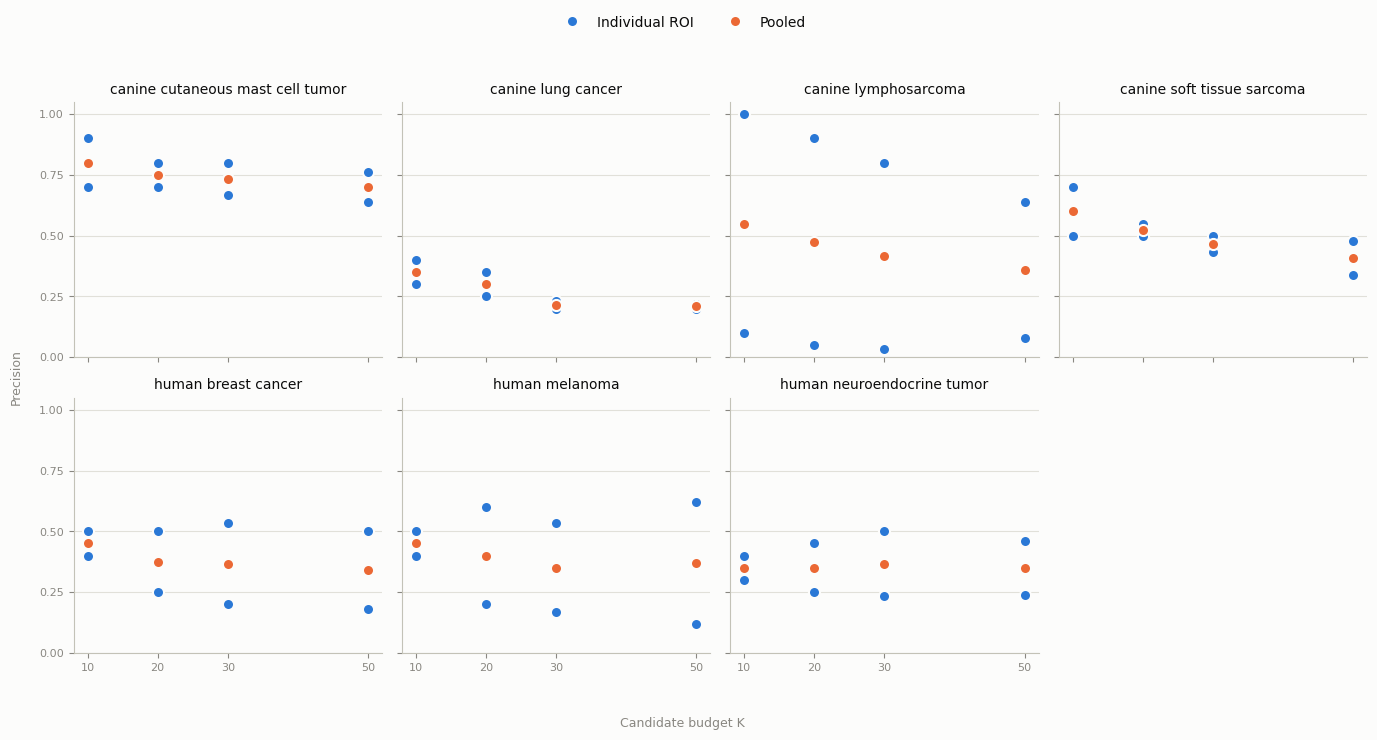

In [7]:
COLOR_ROI = '#2a78d6'
COLOR_POOLED = '#eb6834'
SURFACE = '#fcfcfb'
GRID = '#e1e0d9'
AXIS = '#c3c2b7'
MUTED = '#898781'
INK = '#0b0b0b'

domains = sorted(TABLE_A['domain'].unique())
by_domain_k = TABLE_B.set_index(['domain', 'K'])

fig, axes = plt.subplots(2, 4, figsize=(14, 7.2), sharex=True, sharey=True, facecolor=SURFACE)
axes = axes.ravel()

for ax, domain in zip(axes, domains):
    ax.set_facecolor(SURFACE)
    sub = TABLE_A[TABLE_A['domain'] == domain]

    for _, row in sub.iterrows():
        y = [row[f'precision_at_{k}'] for k in BUDGETS]
        ax.plot(BUDGETS, y, 'o', ms=8, color=COLOR_ROI,
                markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=2)

    pooled_y = [by_domain_k.loc[(domain, k), 'precision_pooled'] for k in BUDGETS]
    ax.plot(BUDGETS, pooled_y, 'o', ms=8, color=COLOR_POOLED,
            markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)

    ax.set_title(domain, fontsize=10, color=INK)
    ax.set_xticks(BUDGETS)
    ax.set_ylim(0, 1.05)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=8)

for ax in axes[len(domains):]:
    ax.axis('off')

handles = [
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=COLOR_ROI,
               markeredgecolor=SURFACE, markeredgewidth=1.5, markersize=8,
               label='Individual ROI'),
    plt.Line2D([0], [0], marker='o', color='none', markerfacecolor=COLOR_POOLED,
               markeredgecolor=SURFACE, markeredgewidth=1.5, markersize=8,
               label='Pooled'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.02), labelcolor=INK, fontsize=10)
fig.supxlabel('Candidate budget K', color=MUTED, fontsize=9)
fig.supylabel('Precision', color=MUTED, fontsize=9)
fig.tight_layout(rect=[0.01, 0.03, 1, 0.93])
plt.show()